# Aggregated Scalar Conclusions

This notebook contains some quick stats on `agentic/scalar_experiments/aggregated_results.csv`. This includes how conclusion varies by dataset and perturbation, to ensure that the null distribution has sufficient spread.

In [5]:
# imports
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# read in data
path = Path("../mock_aggregated_results.csv")
df = pd.read_csv(path)

## By Dataset

new ones will be called "response" and "scale"
do one with 0-100
do them separately as well

In [6]:
# basic summary stats by dataset
df.groupby("dataset")["scale"].agg(["mean", "std", "count"])

,mean,std,count
dataset,,,
affairs,48.318182,28.004739,88
auto,46.842105,27.573621,95
bikeshare,46.361345,30.579635,119
boston,50.978261,30.771036,92
heart,50.075472,28.925421,106


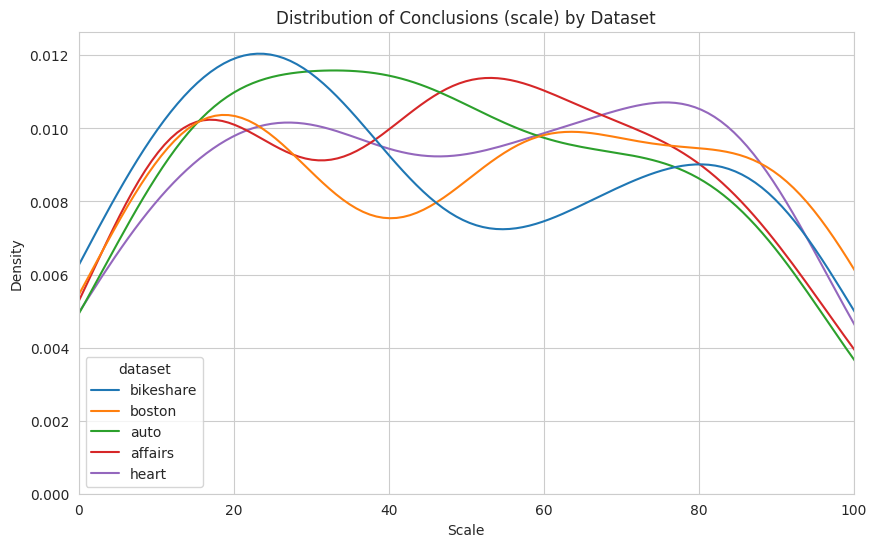

In [7]:
# plot distribution of conclusions by dataset using density plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="scale", hue="dataset", common_norm=False)
plt.title("Distribution of Conclusions (scale) by Dataset")
plt.xlabel("Scale")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

## By perturbation

In [8]:
# basic summary stats by perturbation
df.groupby("perturbation")["scale"].agg(["mean", "std", "count"])

,mean,std,count
perturbation,,,
bootstrap,49.294118,29.926847,119
null_add_features,49.007576,29.162220,132
null_remove_features,45.581197,29.250181,117
null_shuffle_target,49.613636,28.724713,132


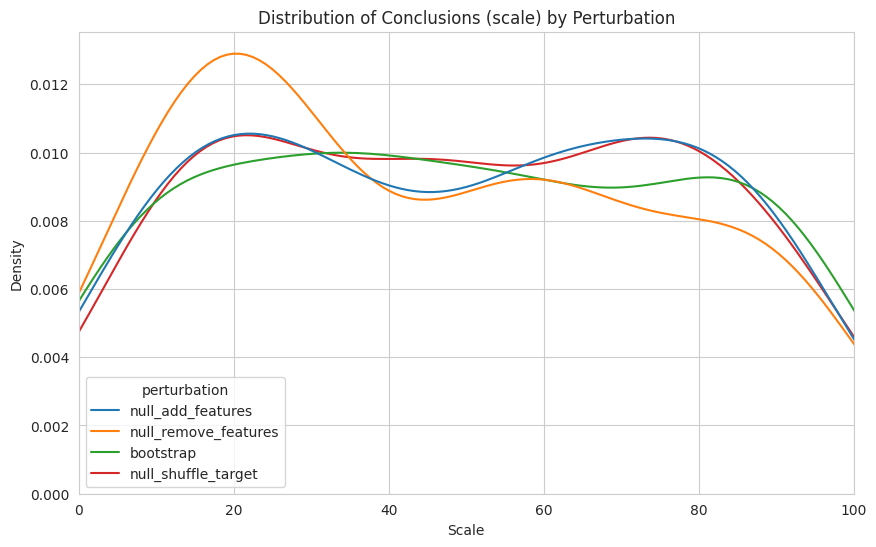

In [9]:
# plot null distribution by perturbation using density plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="scale", hue="perturbation", common_norm=False)
plt.title("Distribution of Conclusions (scale) by Perturbation")
plt.xlabel("Scale")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

## Dataset × Perturbation

In [10]:
# get mean conclusion by dataset and perturbation
print("Mean Scale by dataset and Perturbation:")
df.pivot_table(values="scale", index="dataset", columns="perturbation", aggfunc="mean")

Mean Scale by dataset and Perturbation:


perturbation,bootstrap,null_add_features,null_remove_features,null_shuffle_target
dataset,,,,
affairs,50.842105,47.448276,46.000000,48.916667
auto,54.230769,43.708333,38.954545,49.304348
bikeshare,45.678571,56.037037,45.941176,38.766667
boston,47.941176,49.571429,45.080000,58.862069
heart,48.137931,48.064516,52.550000,52.730769


In [11]:
print('Spread in Scale by Dataset and Perturbation (Std Dev):')
df.pivot_table(values="scale", index="dataset", columns="perturbation", aggfunc="std").round(1)

Spread in Scale by Dataset and Perturbation (Std Dev):


perturbation,bootstrap,null_add_features,null_remove_features,null_shuffle_target
dataset,,,,
affairs,29.8,27.4,30.5,27.2
auto,28.8,25.6,24.9,29.7
bikeshare,32.2,29.3,30.7,29.1
boston,32.2,33.7,30.5,27.8
heart,28.8,30.7,29.8,27.6


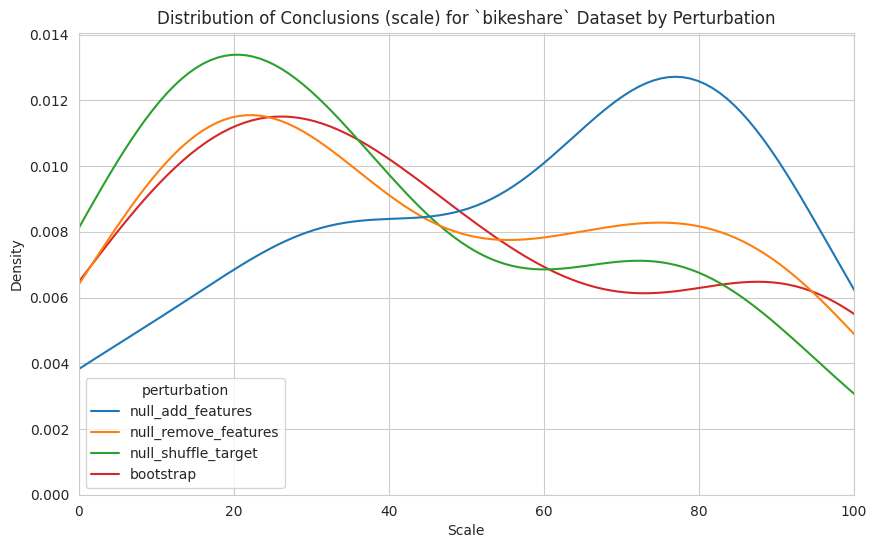

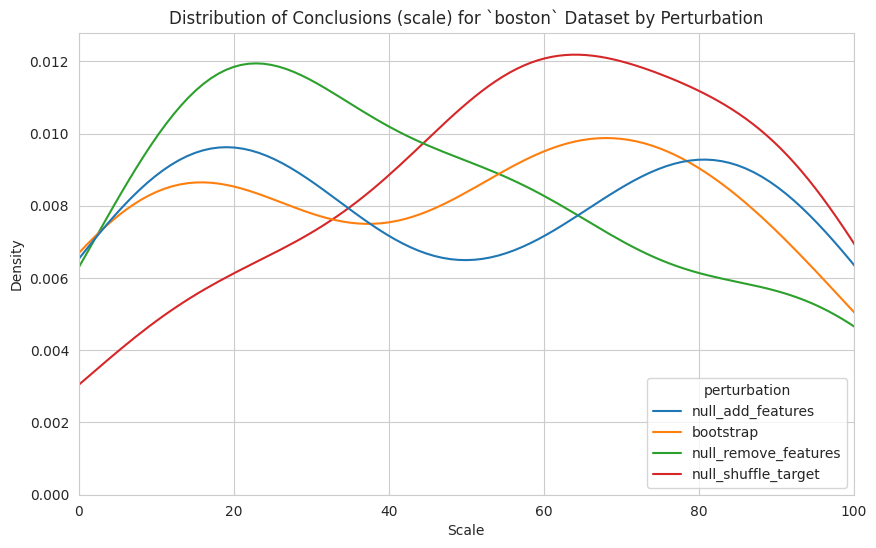

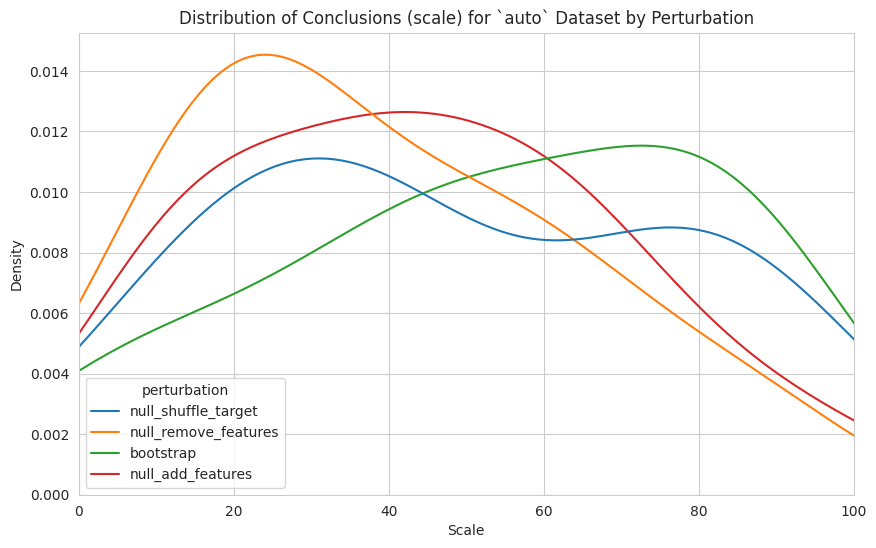

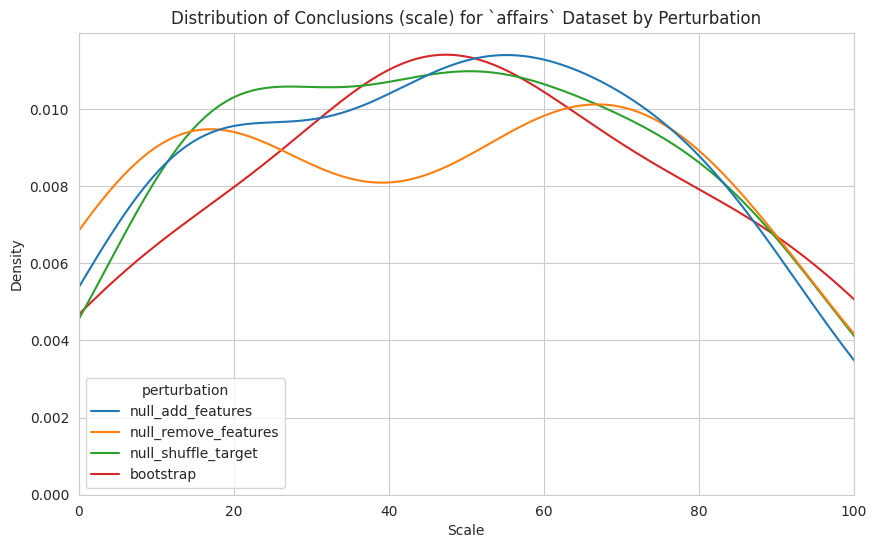

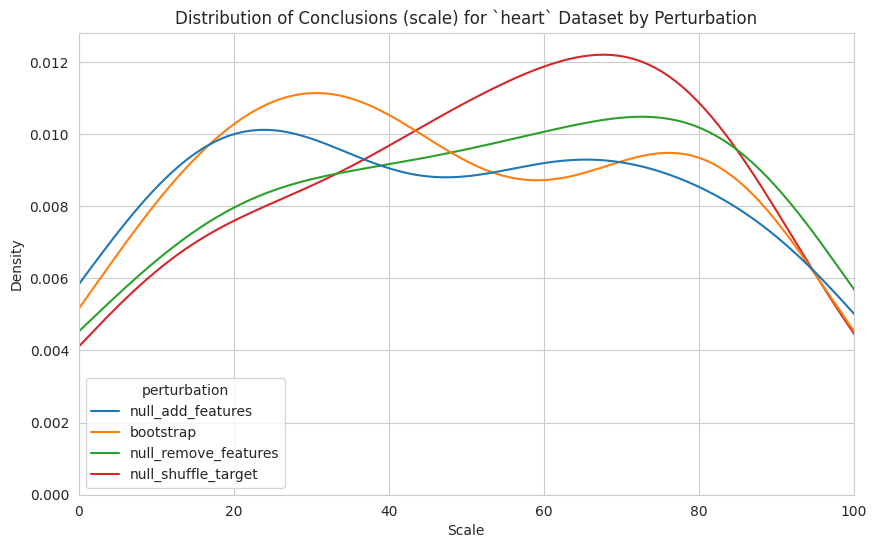

In [12]:
# get list of datasets in results
datasets = df["dataset"].unique()

# plot null distribution for affairs dataset by perturbation
for dataset in datasets:
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df[df["dataset"] == dataset], x="scale", hue="perturbation", common_norm=False)
    plt.title(f"Distribution of Conclusions (scale) for `{dataset}` Dataset by Perturbation")
    plt.xlabel("Scale")
    plt.ylabel("Density")
    plt.xlim(0, 100)
    plt.show()

## Separate Yes/No. 

In [13]:
df_yes = df[df["response"] == "yes"]
df_no = df[df["response"] == "no"]

print(f"Count of Response 'Yes': {len(df_yes)}")
print(f"Count of Response 'No': {len(df_no)}")

Count of Response 'Yes': 283
Count of Response 'No': 217


### Response: Yes

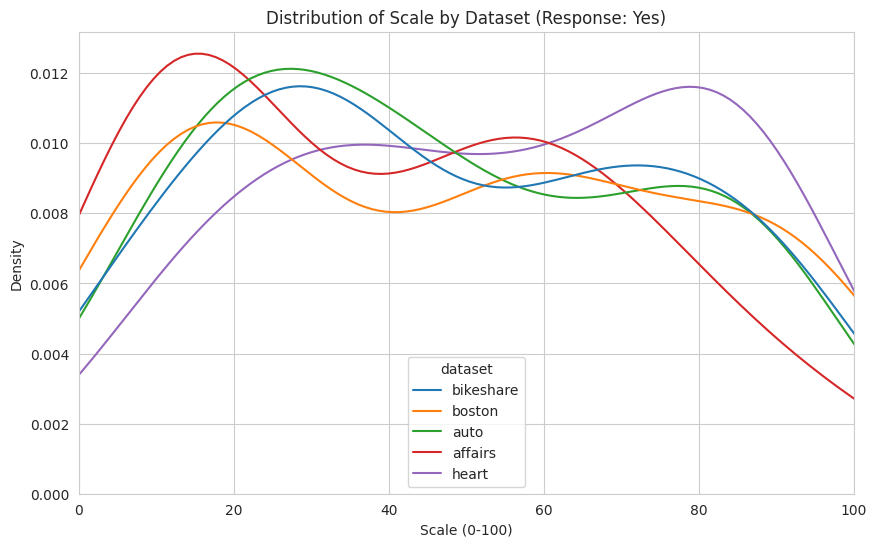

In [14]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_yes, x="scale", hue="dataset", common_norm=False)
plt.title("Distribution of Scale by Dataset (Response: Yes)")
plt.xlabel("Scale (0-100)")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

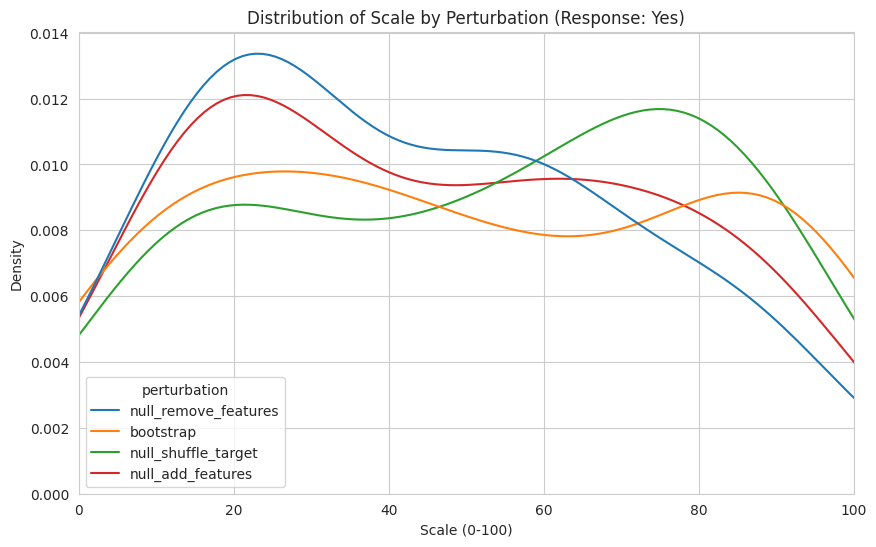

In [15]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_yes, x="scale", hue="perturbation", common_norm=False)
plt.title("Distribution of Scale by Perturbation (Response: Yes)")
plt.xlabel("Scale (0-100)")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

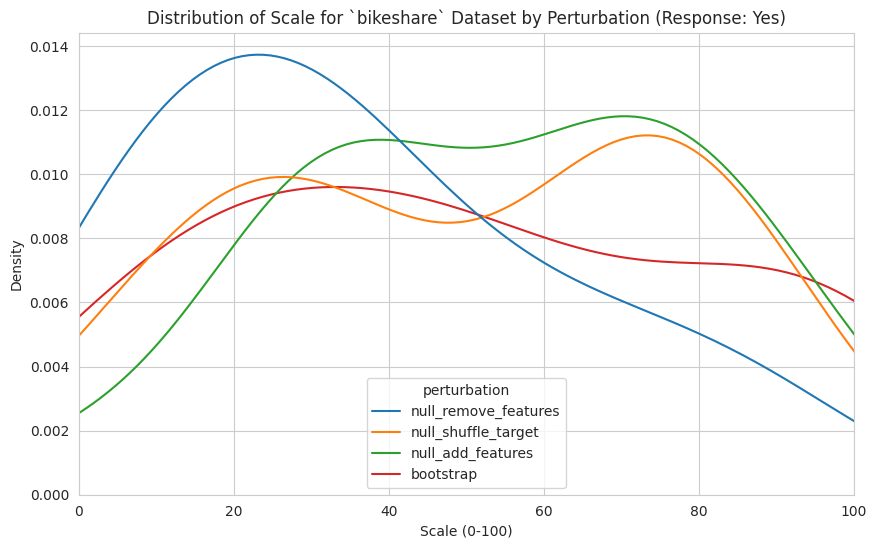

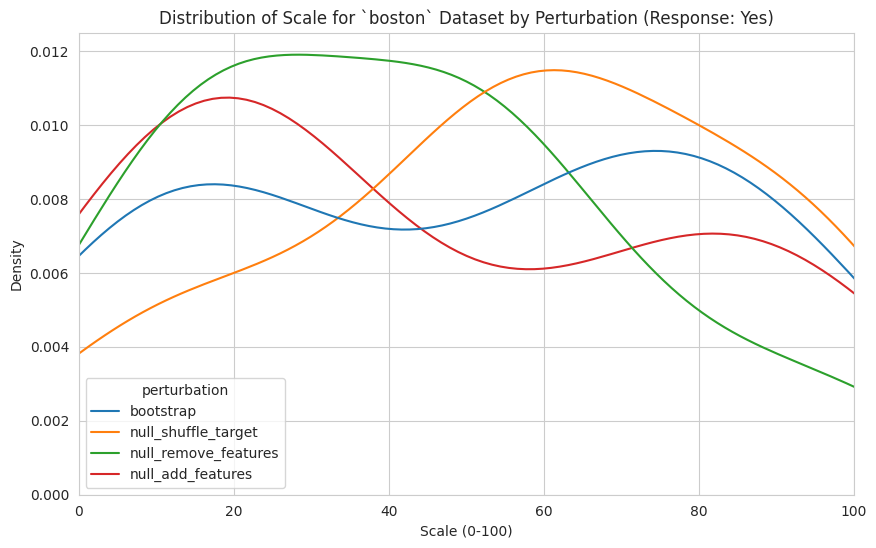

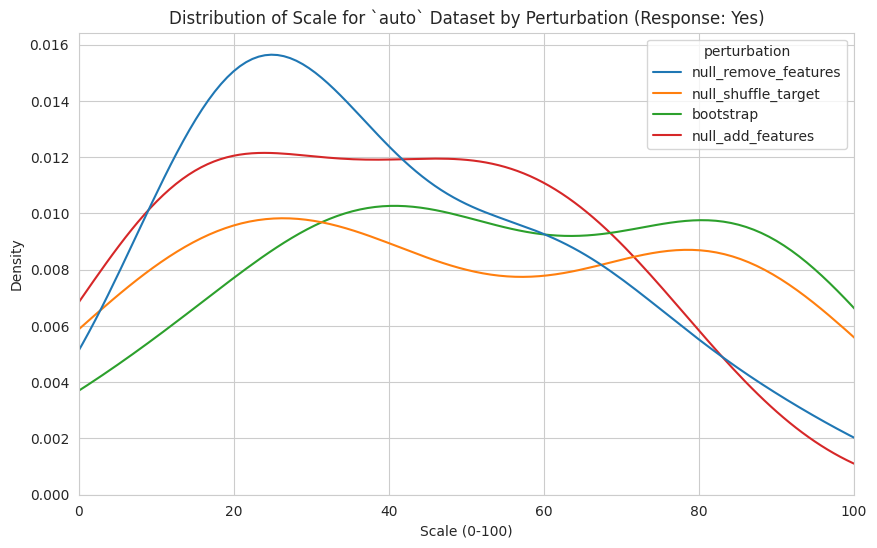

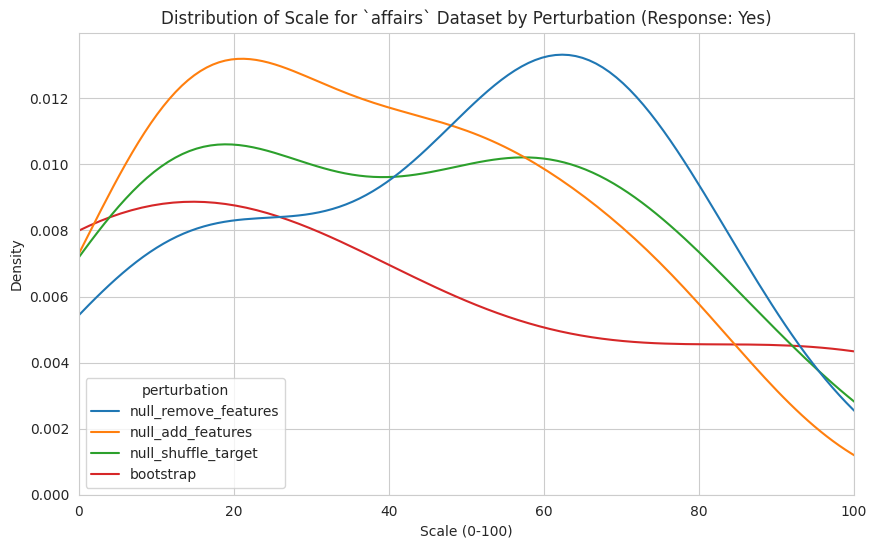

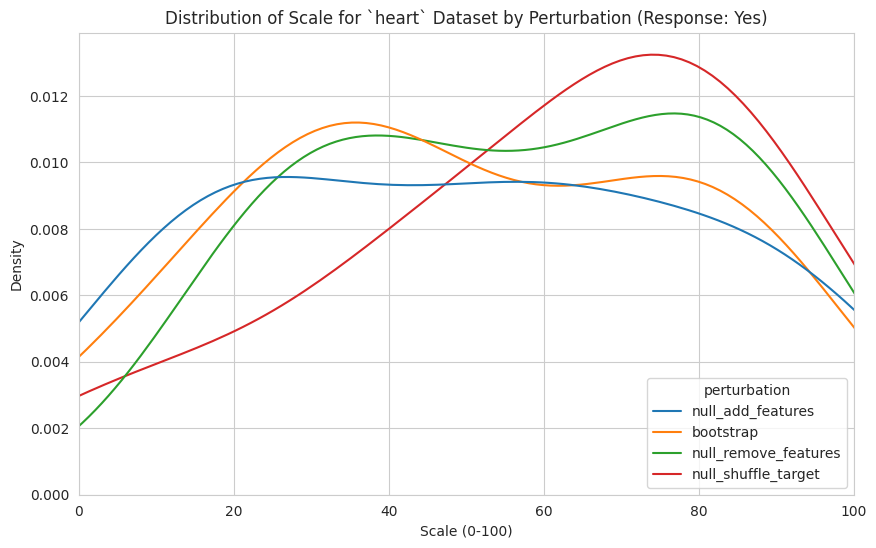

In [16]:
datasets = df["dataset"].unique()
for dataset in datasets:
    subset = df_yes[df_yes["dataset"] == dataset]
    if len(subset) > 0:
        sns.set_style("whitegrid")
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=subset, x="scale", hue="perturbation", common_norm=False)
        plt.title(f"Distribution of Scale for `{dataset}` Dataset by Perturbation (Response: Yes)")
        plt.xlabel("Scale (0-100)")
        plt.ylabel("Density")
        plt.xlim(0, 100)
        plt.show()

### Response: No

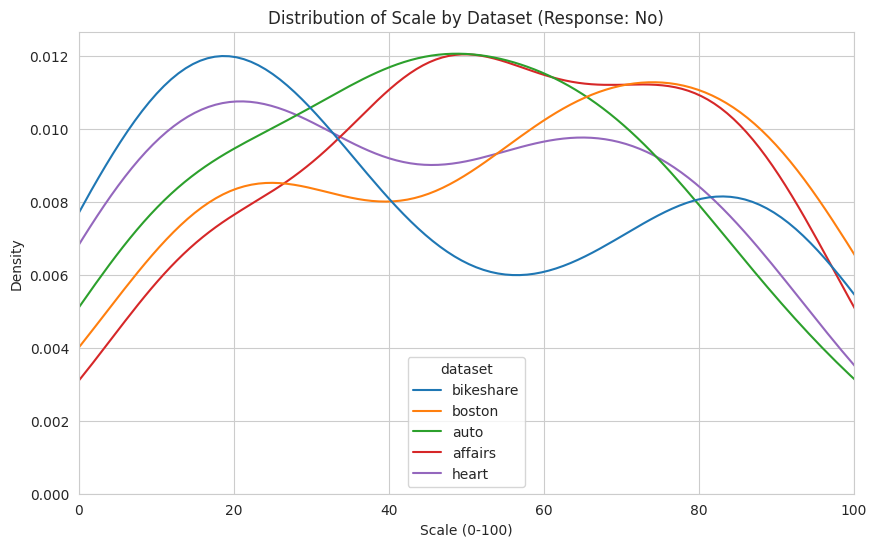

In [17]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_no, x="scale", hue="dataset", common_norm=False)
plt.title("Distribution of Scale by Dataset (Response: No)")
plt.xlabel("Scale (0-100)")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

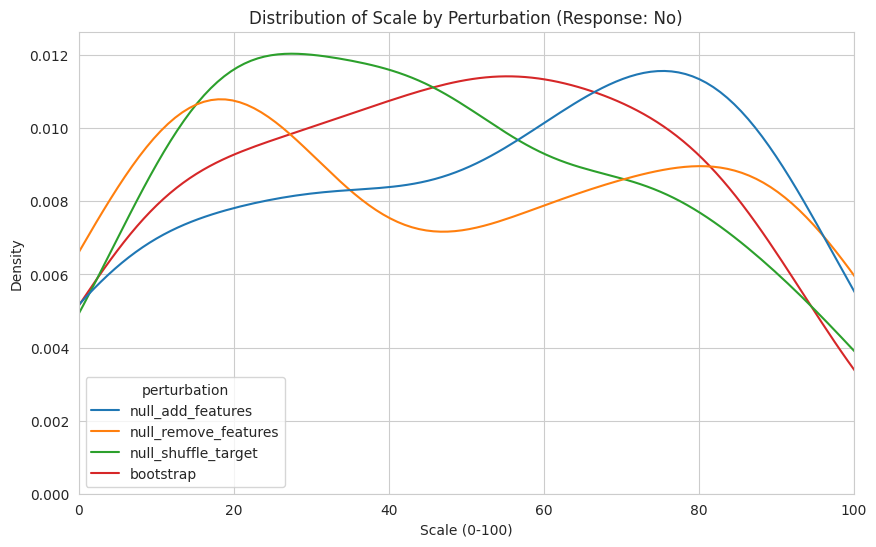

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_no, x="scale", hue="perturbation", common_norm=False)
plt.title("Distribution of Scale by Perturbation (Response: No)")
plt.xlabel("Scale (0-100)")
plt.ylabel("Density")
plt.xlim(0, 100)
plt.show()

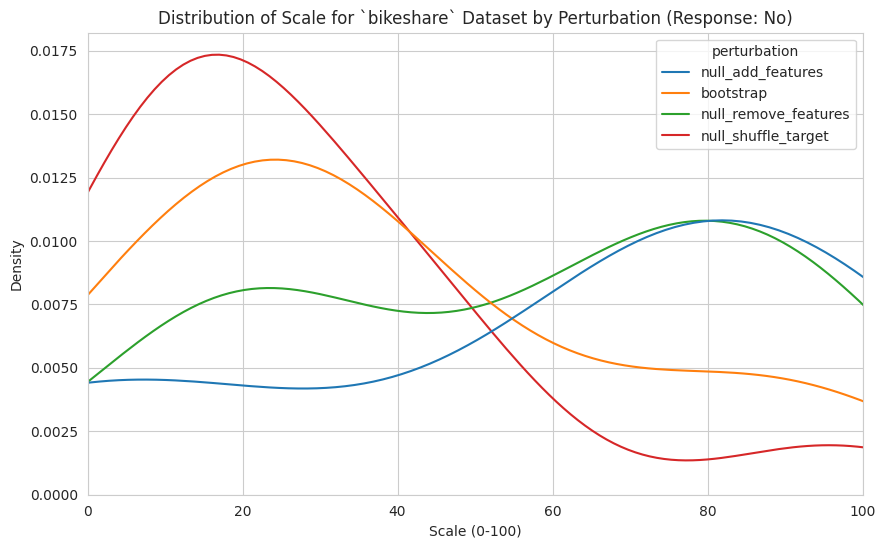

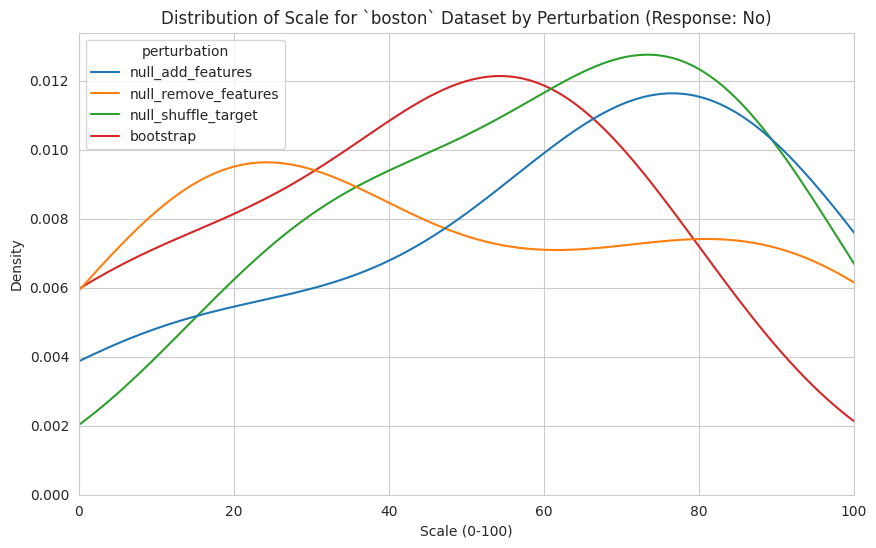

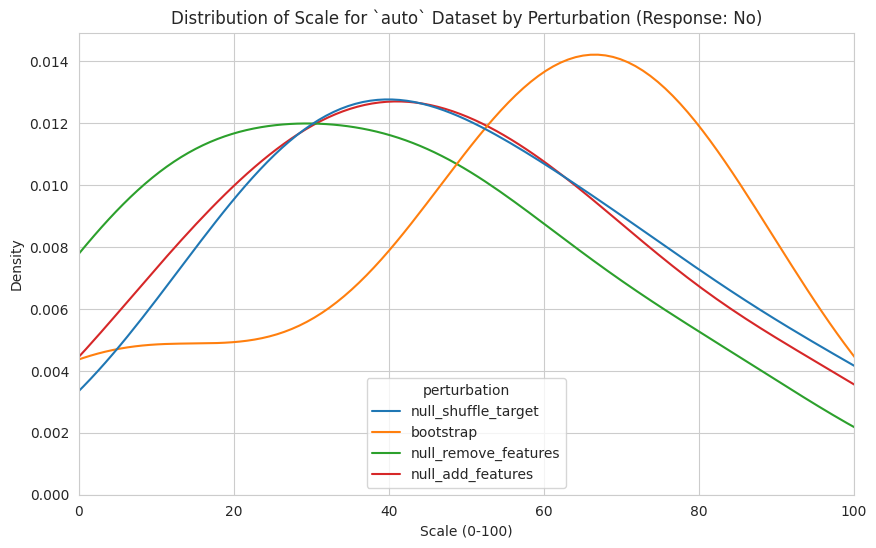

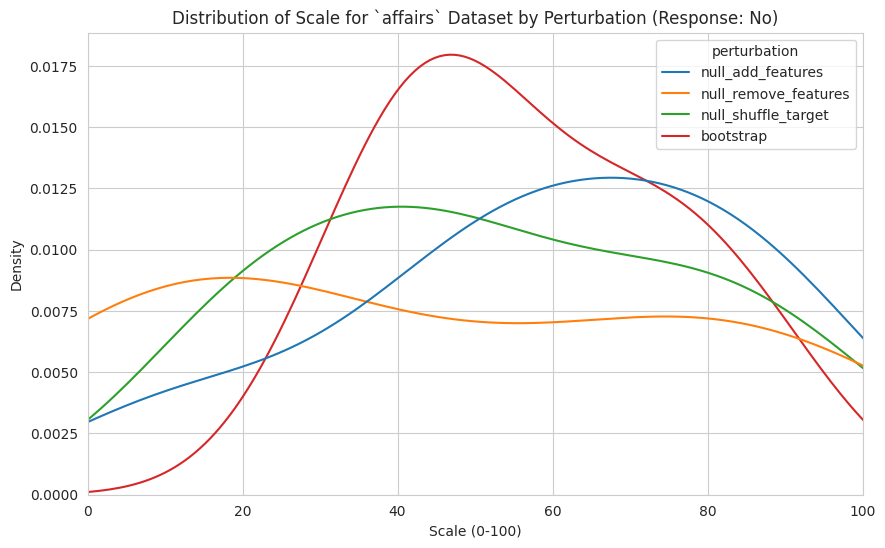

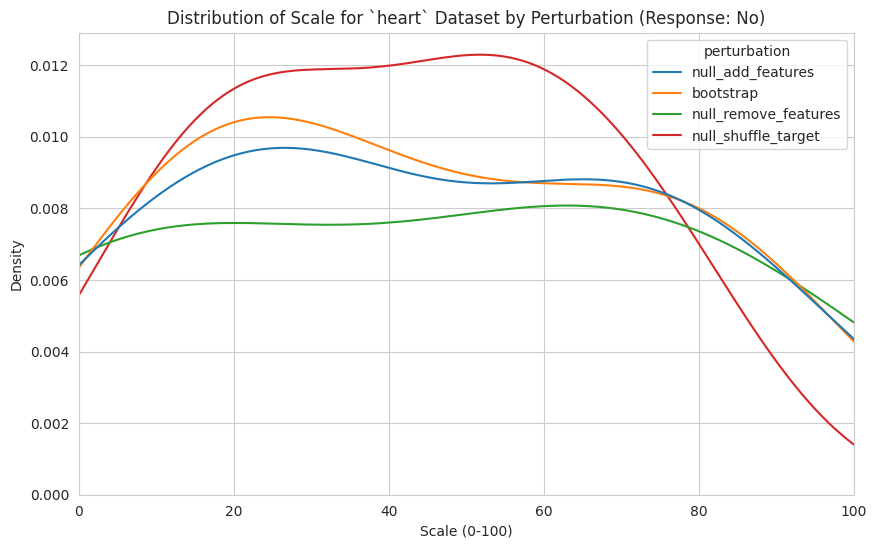

In [19]:
for dataset in datasets:
    subset = df_no[df_no["dataset"] == dataset]
    if len(subset) > 0:
        sns.set_style("whitegrid")
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data=subset, x="scale", hue="perturbation", common_norm=False)
        plt.title(f"Distribution of Scale for `{dataset}` Dataset by Perturbation (Response: No)")
        plt.xlabel("Scale (0-100)")
        plt.ylabel("Density")
        plt.xlim(0, 100)
        plt.show()